In [46]:
import pandas as pd

file_path = "../Data/processed/transportation_2025_clean.parquet"

# Load the cleaned 2025 dataset created in the previous notebook.
df = pd.read_parquet(file_path)

# Check the number of rows and columns in the cleaned dataset.
df.shape

(6879485, 34)

In [47]:
# Take a quick look at the cleaned data.

df.head()

,FlightDate,Year,Month,DayOfWeek,Reporting_Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,...,TaxiIn,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,Route
0,2025-01-01,2025,1,3,AA,JFK,"New York, NY",NY,LAX,"Los Angeles, CA",...,9.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN,6,JFK-LAX
1,2025-01-02,2025,1,4,AA,JFK,"New York, NY",NY,LAX,"Los Angeles, CA",...,7.0,353.0,2475.0,NaN,NaN,NaN,NaN,NaN,6,JFK-LAX
2,2025-01-03,2025,1,5,AA,JFK,"New York, NY",NY,LAX,"Los Angeles, CA",...,11.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN,6,JFK-LAX
3,2025-01-04,2025,1,6,AA,JFK,"New York, NY",NY,LAX,"Los Angeles, CA",...,10.0,349.0,2475.0,NaN,NaN,NaN,NaN,NaN,7,JFK-LAX
4,2025-01-05,2025,1,7,AA,JFK,"New York, NY",NY,LAX,"Los Angeles, CA",...,5.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN,6,JFK-LAX


In [48]:
# Check the dataset structure, data types, and non-null counts.

df.info()

# Check whether the dataset structure matches what I expected.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6879485 entries, 0 to 6879484
Data columns (total 34 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FlightDate         datetime64[us]
 1   Year               int64         
 2   Month              int64         
 3   DayOfWeek          int64         
 4   Reporting_Airline  object        
 5   Origin             object        
 6   OriginCityName     object        
 7   OriginState        object        
 8   Dest               object        
 9   DestCityName       object        
 10  DestState          object        
 11  CRSDepTime         int64         
 12  DepTime            float64       
 13  DepDelay           float64       
 14  DepDelayMinutes    float64       
 15  DepDel15           float64       
 16  DepTimeBlk         object        
 17  TaxiOut            float64       
 18  CRSArrTime         int64         
 19  ArrTime            float64       
 20  ArrDelay           float

In [49]:
# Calculate basic delay metrics to get an overall view of flight performance.

print("Average Departure delay time :", df["DepDelay"].mean())
print("Average Arrival delay time :", df["ArrDelay"].mean())
print("15+ Minute Arrival Delay Rate :", df["ArrDel15"].mean())

Average Departure delay time : 13.46159298261425
Average Arrival delay time : 8.504503680799315
15+ Minute Arrival Delay Rate : 0.2230745794306666


In [50]:
# Examine how the 15+ minute arrival delay rate changes by scheduled departure hour.

df.groupby("DepHour")["ArrDel15"].mean()

DepHour
0     0.165418
1     0.171530
2     0.208622
3     0.178962
4     0.134228
5     0.088519
6     0.100564
7     0.127314
8     0.144687
9     0.158277
10    0.172570
11    0.193902
12    0.210969
13    0.227045
14    0.257709
15    0.279160
16    0.296563
17    0.312488
18    0.317657
19    0.325795
20    0.317783
21    0.290675
22    0.288449
23    0.199669
24    1.000000
Name: ArrDel15, dtype: float64

In [51]:
# Convert the single 24:00 value to hour 0, like the other midnight values,
# for consistent time-of-day analysis.

df["DepHour"] = df["DepHour"].replace(24, 0)

In [52]:
# Check the number of flights recorded for each month.

df.groupby("Month")["Route"].count()

Month
1     522269
2     496476
3     592301
4     577730
5     597574
6     599472
7     612811
8     593733
9     558329
10    601570
11    555296
12    571924
Name: Route, dtype: int64

In [53]:
# Calculate the 15+ minute arrival delay rate for each month.

monthly_delay = df.groupby("Month")["ArrDel15"].mean()

monthly_delay

Month
1     0.187892
2     0.207668
3     0.195904
4     0.196639
5     0.236018
6     0.282590
7     0.288853
8     0.225556
9     0.166316
10    0.203220
11    0.205602
12    0.267716
Name: ArrDel15, dtype: float64

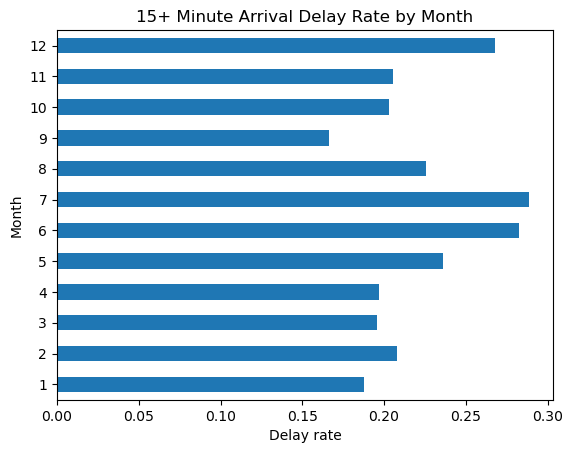

In [54]:
# Visualize monthly 15+ minute arrival delay rates.

import matplotlib.pyplot as plt

monthly_delay.plot (
    kind="barh",
    title="15+ Minute Arrival Delay Rate by Month"
)

plt.xlabel("Delay rate")
plt.ylabel("Month")
plt.show()

In [55]:
# Calculate the 15+ minute arrival delay rate for each airline
# to compare airline performance.

airline_delay= (df.groupby("Reporting_Airline")["ArrDel15"].mean().sort_values(ascending=False))

airline_delay

Reporting_Airline
F9    0.279116
OH    0.275298
B6    0.261523
AA    0.257114
G4    0.249654
AS    0.231008
YX    0.215113
UA    0.214674
NK    0.214084
WN    0.213951
MQ    0.210393
OO    0.207217
DL    0.197942
HA    0.172811
Name: ArrDel15, dtype: float64

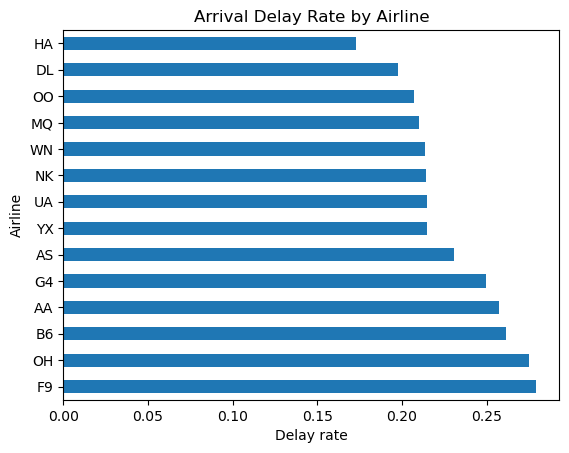

In [56]:
# Visualize arrival delay rates by airline.

airline_delay.plot(
    kind="barh",
    title="Arrival Delay Rate by Airline"
)

plt.xlabel("Delay rate")
plt.ylabel("Airline")
plt.show()

In [57]:
# Calculate the arrival delay rate for each airline and origin airport combination.
# This helps identify operational differences across airport and airline combinations.

airport_delay = df.groupby(["Reporting_Airline","Origin"])["ArrDel15"].mean().sort_values(ascending=False)

airport_delay

Reporting_Airline  Origin
DL                 SHV       1.000000
MQ                 SFO       1.000000
OH                 SAF       1.000000
F9                 STX       0.714286
HA                 ANC       0.691824
                               ...   
UA                 BTR       0.000000
OH                 SAT       0.000000
                   CHO       0.000000
MQ                 LAS       0.000000
OH                 PHF       0.000000
Name: ArrDel15, Length: 1640, dtype: float64

In [58]:
# Use flight count because small samples can make delay rates look exaggerated.
# Only groups with at least 100 flights are included for a more reliable comparison.

df.groupby(["Reporting_Airline","Origin"])["ArrDel15"].agg(["mean","count"]).query("count >= 100").sort_values("mean")

mean  count
Reporting_Airline Origin                 
OO                EKO     0.035785    503
WN                ITO     0.040850   1836
                  KOA     0.047491   2969
                  LIH     0.048871   2967
OO                TWF     0.048951    715
...                            ...    ...
G4                HGR     0.496753    308
                  CKB     0.517588    199
                  LIT     0.543478    138
                  TRI     0.625000    176
HA                ANC     0.691824    159

[1521 rows x 2 columns]

In [59]:
# Compare the average delay minutes associated with each delay cause.

df[[
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]].mean()

CarrierDelay         23.670975
WeatherDelay          4.632176
NASDelay             15.954095
SecurityDelay         0.099569
LateAircraftDelay    28.581966
dtype: float64

In [60]:
# Mean excludes NaN values, so count is included to better understand
# how often each delay cause is recorded.

delay_causes = df[
    ["CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
    ]
].agg(["mean", "count"])

delay_causes

,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
mean,2.367097e+01,4.632176e+00,1.595410e+01,9.956876e-02,2.858197e+01
count,1.534638e+06,1.534638e+06,1.534638e+06,1.534638e+06,1.534638e+06


In [61]:
# Since all delay-cause columns have the same count, inspect the values
# to understand why they have the same count.

df[
    [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
    ]
].head(20)

# A delay cause is recorded as 0 when it does not contribute to the delay.

,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


In [62]:
# Convert delay values into True/False, then use sum() to count actual occurrences.

delay_counts=(df[
    [
    "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay"
    ]
]>0).sum()

delay_counts

CarrierDelay         805311
WeatherDelay         100103
NASDelay             793120
SecurityDelay          5100
LateAircraftDelay    774405
dtype: int64

In [63]:
# Calculate the total delay minutes contributed by each delay cause.
# This helps identify which causes have the greatest overall impact.

delay_totals = df[
    [
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay"
    ]
].sum().sort_values(ascending=False)

delay_totals

LateAircraftDelay    43862971.0
CarrierDelay         36326377.0
NASDelay             24483761.0
WeatherDelay          7108714.0
SecurityDelay          152802.0
dtype: float64

In [64]:
# Combine delay occurrence counts and total delay minutes into one summary table.

delay_summary = pd.DataFrame({
    "Count": delay_counts,
    "TotalDelayMinutes": delay_totals
})

delay_summary

,Count,TotalDelayMinutes
CarrierDelay,805311,36326377.0
LateAircraftDelay,774405,43862971.0
NASDelay,793120,24483761.0
SecurityDelay,5100,152802.0
WeatherDelay,100103,7108714.0


In [65]:
# Calculate the 15+ minute arrival delay rate for each route
# to identify routes with higher delay rates.
# Only routes with at least 100 flights are included to reduce the effect of small samples.

df.groupby("Route")["ArrDel15"].agg(["mean","count"]).query("count>=100").sort_values("mean", ascending=False)

,mean,count
Route,,
ROA-SFB,0.672000,125
TRI-SFB,0.642276,123
CKB-SFB,0.616071,112
LEX-SFB,0.613636,220
TOL-SFB,0.585586,111
...,...,...
HLN-SLC,0.037448,721
TUS-MDW,0.037249,349
KOA-LAS,0.035912,362


In [66]:
# Calculate the 15+ minute arrival delay rate for each day of the week.

day_delay = df.groupby("DayOfWeek")["ArrDel15"].mean()

day_delay.index = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_delay

Monday       0.237844
Tuesday      0.183886
Wednesday    0.192884
Thursday     0.233211
Friday       0.232520
Saturday     0.210030
Sunday       0.263590
Name: ArrDel15, dtype: float64

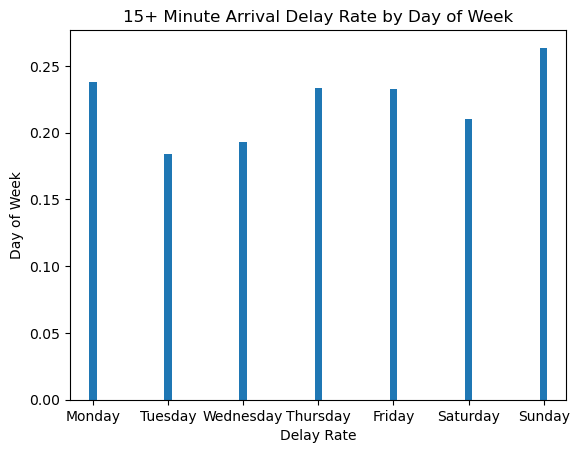

In [67]:
# Visualize the 15+ minute arrival delay rate by day of the week.

day_delay.plot(
    kind="bar",
    width=0.1,
    title="15+ Minute Arrival Delay Rate by Day of Week",
    rot=0

)

plt.xlabel("Delay Rate")
plt.ylabel("Day of Week")
plt.show()